<a href="https://colab.research.google.com/github/Dh33na-B/--SSI-Wallet--/blob/main/ml_mini_project_mobile_net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Unzipping the dataset

In [ ]:
!wget -c -O plantseg.zip "https://zenodo.org/records/17719108/files/plantseg.zip?download=1"

--2026-03-28 05:42:31--  https://zenodo.org/records/17719108/files/plantseg.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 188.184.98.114, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1057281724 (1008M) [application/octet-stream]
Saving to: ‘plantseg.zip’

plantseg.zip        100%[===================>]   1008M  19.3MB/s    in 55s     

2026-03-28 05:43:27 (18.3 MB/s) - ‘plantseg.zip’ saved [1057281724/1057281724]



In [ ]:
!unzip -q plantseg.zip -d plantseg

# Checking folder structure

In [ ]:
import os

os.listdir("plantseg/plantseg")

['annotation_test.json',
 'images',
 'annotation_train.json',
 'annotation_val.json',
 'Metadata.csv',
 'annotations']

In [ ]:
for root, dirs, files in os.walk("plantseg/plantseg"):
    print("Root:", root)
    print("Folders:", dirs)
    print("Files:", len(files))


Root: plantseg/plantseg
Folders: ['images', 'annotations']
Files: 4
Root: plantseg/plantseg/images
Folders: ['train', 'test', 'val']
Files: 0
Root: plantseg/plantseg/images/train
Folders: []
Files: 5367
Root: plantseg/plantseg/images/test
Folders: []
Files: 1561
Root: plantseg/plantseg/images/val
Folders: []
Files: 846
Root: plantseg/plantseg/annotations
Folders: ['train', 'test', 'val']
Files: 0
Root: plantseg/plantseg/annotations/train
Folders: []
Files: 5367
Root: plantseg/plantseg/annotations/test
Folders: []
Files: 1561
Root: plantseg/plantseg/annotations/val
Folders: []
Files: 846


# Validating the image annotations

In [ ]:
import os

base_path = "plantseg/plantseg"

img_train = sorted(os.listdir(f"{base_path}/images/train"))
mask_train = sorted(os.listdir(f"{base_path}/annotations/train"))

print("Images:", len(img_train))
print("Masks:", len(mask_train))

for i in range(5):
    print(img_train[i], " <-> ", mask_train[i])

Images: 5367
Masks: 5367
apple_black_rot_1.jpg  <->  apple_black_rot_1.png
apple_black_rot_11.jpg  <->  apple_black_rot_11.png
apple_black_rot_12.jpg  <->  apple_black_rot_12.png
apple_black_rot_15.jpg  <->  apple_black_rot_15.png
apple_black_rot_156.jpg  <->  apple_black_rot_156.png


# Loading the dataset

In [ ]:
import pandas as pd
import re

data = []

extra = {'google', 'bing', 'baidu', 'black'}  # remove unwanted tokens

for name in img_train:
    words = name.split("_")[:-1]

    # remove noisy words (case insensitive)
    words = [w for w in words if w.lower() not in extra]

    # remove brackets
    words = [re.sub(r'[()]', '', w) for w in words]

    label = "_".join(words)
    data.append((name, label))

df = pd.DataFrame(data, columns=["image", "label"])

# Get unique classes
classes = sorted(df["label"].unique())

print("Total classes:", len(classes))
print(classes)

Total classes: 115
['apple_mosaic_virus', 'apple_rot', 'apple_rust', 'apple_scab', 'banana_anthracnose', 'banana_bunchy_top', 'banana_cigar_end_rot', 'banana_cordana_leaf_spot', 'banana_leaf_streak', 'banana_panama_disease', 'basil_downy_mildew', 'bean_halo_blight', 'bean_mosaic_virus', 'bean_rust', 'bell_pepper_bacterial_spot', 'bell_pepper_blossom_end_rot', 'bell_pepper_frogeye_leaf_spot', 'bell_pepper_powdery_mildew', 'blueberry_anthracnose', 'blueberry_botrytis_blight', 'blueberry_mummy_berry', 'blueberry_rust', 'blueberry_scorch', 'broccoli_alternaria_leaf_spot', 'broccoli_downy_mildew', 'broccoli_ring_spot', 'cabbage_alternaria_leaf_spot', 'cabbage_downy_mildew', 'cabbage_rot', 'carrot_alternaria_leaf_blight', 'carrot_cavity_spot', 'carrot_cercospora_leaf_blight', 'cauliflower_alternaria_leaf_spot', 'cauliflower_bacterial_soft_rot', 'celery_anthracnose', 'celery_early_blight', 'cherry_leaf_spot', 'cherry_powdery_mildew', 'citrus_canker', 'citrus_greening_disease', 'coffee_berry_b

In [ ]:
df['label'].unique()

array(['apple_rot', 'apple_mosaic_virus', 'apple_rust', 'apple_scab',
       'banana_anthracnose', 'banana_leaf_streak', 'banana_bunchy_top',
       'banana_cigar_end_rot', 'banana_cordana_leaf_spot',
       'banana_panama_disease', 'basil_downy_mildew', 'bean_halo_blight',
       'bean_mosaic_virus', 'bean_rust', 'bell_pepper_bacterial_spot',
       'bell_pepper_blossom_end_rot', 'bell_pepper_frogeye_leaf_spot',
       'bell_pepper_powdery_mildew', 'blueberry_anthracnose',
       'blueberry_botrytis_blight', 'blueberry_mummy_berry',
       'blueberry_rust', 'blueberry_scorch',
       'broccoli_alternaria_leaf_spot', 'broccoli_downy_mildew',
       'broccoli_ring_spot', 'cabbage_alternaria_leaf_spot',
       'cabbage_rot', 'cabbage_downy_mildew',
       'carrot_alternaria_leaf_blight', 'carrot_cavity_spot',
       'carrot_cercospora_leaf_blight',
       'cauliflower_alternaria_leaf_spot',
       'cauliflower_bacterial_soft_rot', 'celery_anthracnose',
       'celery_early_blight', 'cher

In [ ]:
summary_df = df["label"].value_counts().reset_index()
summary_df.columns = ["Disease", "Count"]
summary_df

,Disease,Count
0,citrus_canker,225
1,wheat_head_scab,161
2,wheat_stripe_rust,160
3,grape_downy_mildew,148
4,wheat_powdery_mildew,119
...,...,...
110,celery_anthracnose,7
111,plum_bacterial_spot,6
112,peach_anthracnose,6
113,peach_rust,4


<Figure size 5000x5000 with 0 Axes>

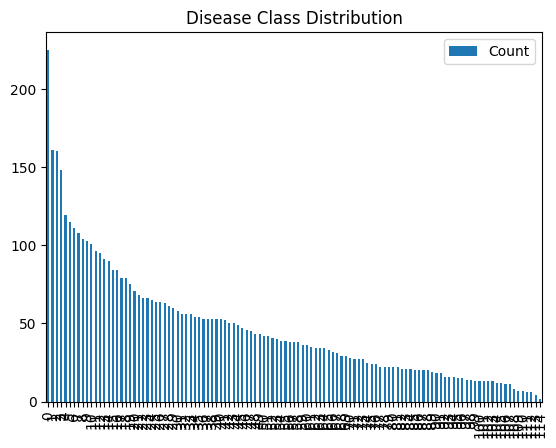

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(50,50))
summary_df.plot(kind="bar")
plt.xticks(rotation=90)
plt.title("Disease Class Distribution")
plt.show()

In [ ]:
df.describe()

,image,label
count,5367,5367
unique,5367,115
top,zucchini_yellow_mosaic_virus_google_0173.jpg,citrus_canker
freq,1,225


# Creating the classification dataset

In [ ]:
import os

new_base = "plant_classification"
splits = ["train", "val", "test"]

for split in splits:
    os.makedirs(f"{new_base}/{split}", exist_ok=True)

print("Base folders created")

Base folders created


In [ ]:
import shutil

base_path = "plantseg/plantseg/images"

extra = {'google', 'bing', 'baidu', 'black'}  # remove unwanted tokens

for split in splits:
    split_path = f"{base_path}/{split}"

    for filename in os.listdir(split_path):

        words = filename.split("_")[:-1]
        words = [w for w in words if w.lower() not in extra]
        words = [re.sub(r'[()]', '', w) for w in words]

        label = "_".join(words)

        class_dir = f"{new_base}/{split}/{label}"
        os.makedirs(class_dir, exist_ok=True)

        src = os.path.join(split_path, filename)
        dst = os.path.join(class_dir, filename)
        shutil.copy(src, dst)

print("Classification dataset created successfully")

Classification dataset created successfully


In [ ]:
import shutil

# Folder to zip
folder_to_zip = "plant_classification"

# Name of output zip file (without .zip extension)
output_zip_name = "plant_classification"

# Create zip file
shutil.make_archive(output_zip_name, 'zip', folder_to_zip)

print("Zip file created successfully")

Zip file created successfully


###**Exploratory Data Analysis**

Directory structure

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os

base_path = "plantseg/plantseg"

for root, dirs, files in os.walk(base_path):
    print(f"\nFolder: {root}")
    print(f"Subfolders: {dirs}")
    print(f"Files count: {len(files)}")


Folder: plantseg/plantseg
Subfolders: ['images', 'annotations']
Files count: 4

Folder: plantseg/plantseg/images
Subfolders: ['train', 'test', 'val']
Files count: 0

Folder: plantseg/plantseg/images/train
Subfolders: []
Files count: 5367

Folder: plantseg/plantseg/images/test
Subfolders: []
Files count: 1561

Folder: plantseg/plantseg/images/val
Subfolders: []
Files count: 846

Folder: plantseg/plantseg/annotations
Subfolders: ['train', 'test', 'val']
Files count: 0

Folder: plantseg/plantseg/annotations/train
Subfolders: []
Files count: 5367

Folder: plantseg/plantseg/annotations/test
Subfolders: []
Files count: 1561

Folder: plantseg/plantseg/annotations/val
Subfolders: []
Files count: 846


The dataset contains three main components:
1. images/ – contains the plant leaf images used as input.
2. annotations/ – contains segmentation masks highlighting diseased areas.
3. Metadata.csv – contains information about each image such as plant type, disease type, resolution, and dataset split.

Each image has a corresponding mask that identifies the diseased region, indicating that this is a semantic segmentation dataset.

#### **Analysing the meta data**

In [ ]:
df = pd.read_csv("plantseg/plantseg/Metadata.csv")
df.head()

,Name,Index,Plant,Disease,Resolution,Label file,Mask ratio,URL,License,Split
0,apple_black_rot_1.jpg,0,Apple,apple black rot,640x480,apple_black_rot_1.png,0.040439,https://baijiahao.baidu.com/s?id=1592172448991...,CC-BY-NC,Training
1,apple_black_rot_11.jpg,0,Apple,apple black rot,1080x755,apple_black_rot_11.png,0.057550,http://dy.163.com/v2/article/detail/EJ3OGOG605...,CC-BY-NC,Training
2,apple_black_rot_12.jpg,0,Apple,apple black rot,1280x719,apple_black_rot_12.png,0.024791,http://baijiahao.baidu.com/s?id=16205160930871...,CC-BY-NC,Training
3,apple_black_rot_15.jpg,0,Apple,apple black rot,600x355,apple_black_rot_15.png,0.236169,http://www.360doc.cn/article/4310958_180040780...,CC-BY-NC,Training
4,apple_black_rot_156.jpg,0,Apple,apple black rot,219x294,apple_black_rot_156.png,0.054344,http://baijiahao.baidu.com/s?id=16352401074244...,CC-BY-NC,Training


#### **Peculiarity of the metadata**

In [ ]:
df.shape

(7774, 10)

there are 10 columns and 7774 rows that represents the meta data of our image data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7774 entries, 0 to 7773
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        7774 non-null   object 
 1   Index       7774 non-null   int64  
 2   Plant       7774 non-null   object 
 3   Disease     7774 non-null   object 
 4   Resolution  7774 non-null   object 
 5   Label file  7774 non-null   object 
 6   Mask ratio  7774 non-null   float64
 7   URL         7774 non-null   object 
 8   License     7774 non-null   object 
 9   Split       7774 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 607.5+ KB


We have 10 columns name namely

**Name** - name of the image in the images directory  
**Index** - Index of the respective disease  
**Plant** - Name of the affected plant  
**Disease** - Name of the disease caused   
**Resolution** - Resolution of the image   
**Label File** - path to the segmentation mask file located inside the annotations folder   
**Mask ratio** - percentage of image covered by the disease   
**URL** - source URL from the image has been taken   
**License** - license of the image   
**Split** - indicates to which split the image belongs to (test, train, val)


In [ ]:
df.isnull().sum()

,0
Name,0
Index,0
Plant,0
Disease,0
Resolution,0
Label file,0
Mask ratio,0
URL,0
License,0
Split,0


No missing values in the meta data

##### **Target Analysis**

No of diseases:  115


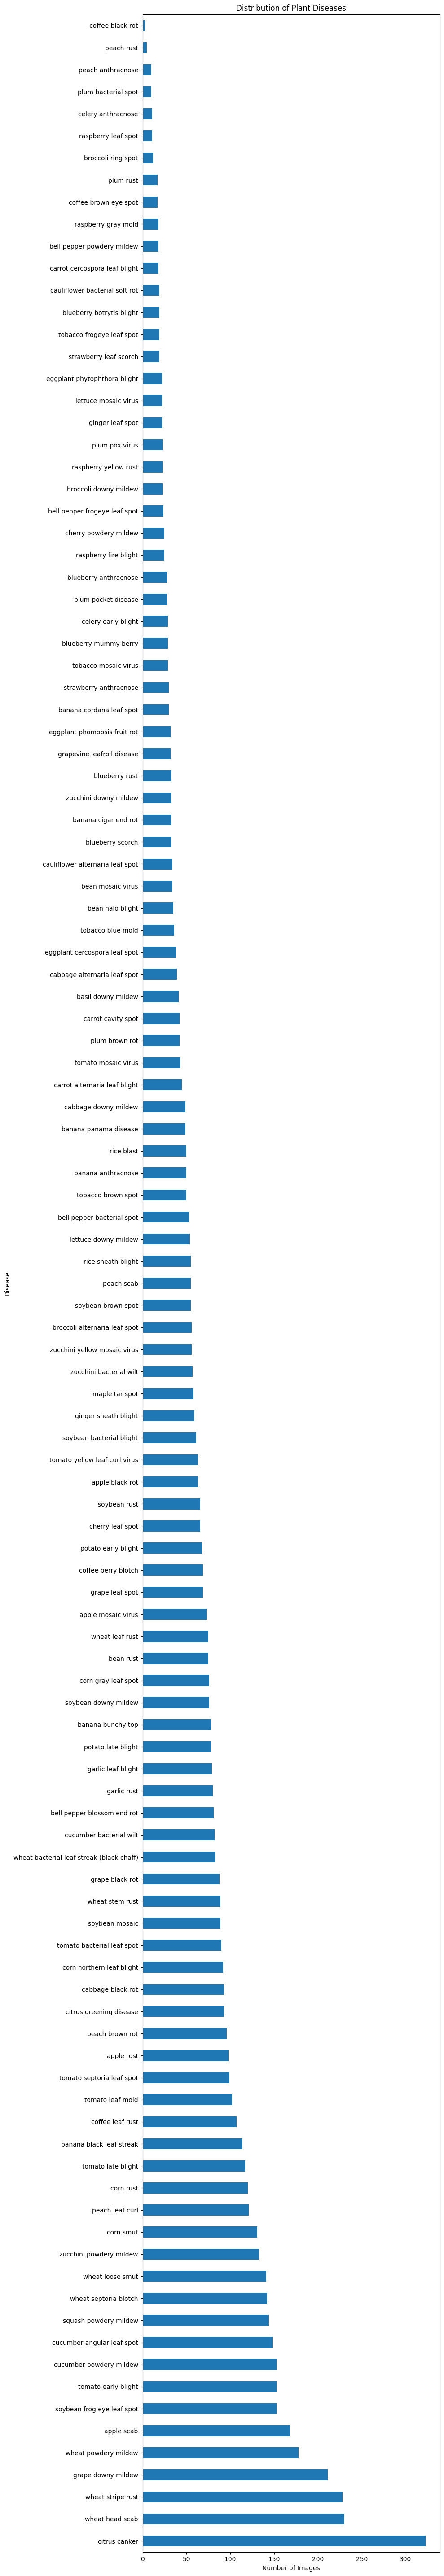

In [ ]:
disease_counts = df["Disease"].value_counts()
print("No of diseases: ", len(disease_counts))
plt.figure(figsize=(10, 0.5 * len(disease_counts)))
disease_counts.plot(kind="barh")

plt.title("Distribution of Plant Diseases")
plt.xlabel("Number of Images")
plt.ylabel("Disease")
plt.tight_layout()

plt.show()

* The dataset contains 115 different plant disease categories (model will be performing multiclass classification)

* number of samples per disease is not uniform and the dataset is highly imbalanced, a few diseases have large number of samples while many diseases have small number of samples.



No of plants:  34


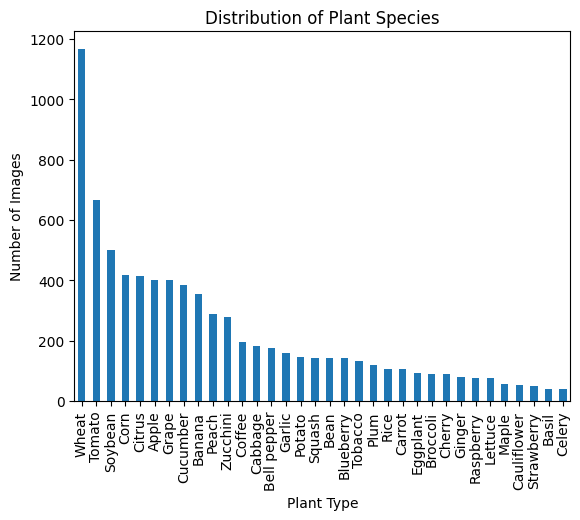

In [ ]:
import matplotlib.pyplot as plt

plant_counts = df["Plant"].value_counts()
print("No of plants: ", len(plant_counts))
plant_counts.plot(kind="bar")
plt.title("Distribution of Plant Species")
plt.xlabel("Plant Type")
plt.ylabel("Number of Images")
plt.show()

There are 34 plant species, the number of images per plant is also not evenly distributed. some plants have drastically more number of images (wheat, tomato, soyabean)

#### **Plant Vs Disease Relationship**

In [ ]:
disease_per_plant = df.groupby("Plant")["Disease"].nunique().sort_values(ascending=False)

print("No of diseases per plant")
print(disease_per_plant)

No of diseases per plant
Plant
Wheat          8
Tomato         7
Soybean        6
Banana         6
Plum           5
Blueberry      5
Peach          5
Apple          4
Corn           4
Bell pepper    4
Raspberry      4
Grape          4
Tobacco        4
Coffee         4
Zucchini       4
Carrot         3
Bean           3
Cabbage        3
Broccoli       3
Cucumber       3
Eggplant       3
Garlic         2
Cauliflower    2
Citrus         2
Cherry         2
Celery         2
Strawberry     2
Potato         2
Lettuce        2
Ginger         2
Rice           2
Basil          1
Maple          1
Squash         1
Name: Disease, dtype: int64


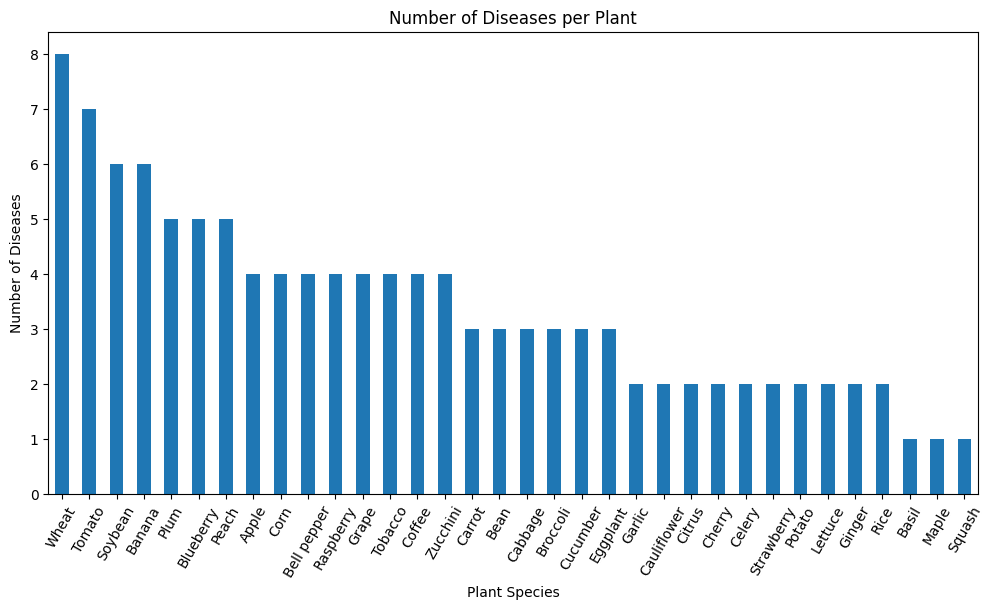

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

disease_per_plant.plot(kind="bar")

plt.title("Number of Diseases per Plant")
plt.xlabel("Plant Species")
plt.ylabel("Number of Diseases")
plt.xticks(rotation=60)

plt.show()

The number of diseases varies significantly across plant species, indicating that some plants are affected by many disease types, while otherrs have very few diseases recoreded in the dataset.

wheat(8 diseases) and Tomato(7 diseases) have the highest number of disease categories. This suggests these crops are more vulnerable to multiple diseases or are more extensively studied.

##### **Healthy vs Diseased image**

In [ ]:
healthy_count = df[df["Disease"].str.contains("healthy", case=False)].shape[0]
diseased_count = df.shape[0] - healthy_count

print("Healthy Images:", healthy_count)
print("Diseased Images:", diseased_count)


Healthy Images: 0
Diseased Images: 7774


##### **Resolution Analysis**

In [ ]:
df[["Width", "Height"]] = df["Resolution"].str.split("x", expand=True)

# convert to integer
df["Width"] = df["Width"].astype(int)
df["Height"] = df["Height"].astype(int)

df.head()

,Name,Index,Plant,Disease,Resolution,Label file,Mask ratio,URL,License,Split,Width,Height
0,apple_black_rot_1.jpg,0,Apple,apple black rot,640x480,apple_black_rot_1.png,0.040439,https://baijiahao.baidu.com/s?id=1592172448991...,CC-BY-NC,Training,640,480
1,apple_black_rot_11.jpg,0,Apple,apple black rot,1080x755,apple_black_rot_11.png,0.057550,http://dy.163.com/v2/article/detail/EJ3OGOG605...,CC-BY-NC,Training,1080,755
2,apple_black_rot_12.jpg,0,Apple,apple black rot,1280x719,apple_black_rot_12.png,0.024791,http://baijiahao.baidu.com/s?id=16205160930871...,CC-BY-NC,Training,1280,719
3,apple_black_rot_15.jpg,0,Apple,apple black rot,600x355,apple_black_rot_15.png,0.236169,http://www.360doc.cn/article/4310958_180040780...,CC-BY-NC,Training,600,355
4,apple_black_rot_156.jpg,0,Apple,apple black rot,219x294,apple_black_rot_156.png,0.054344,http://baijiahao.baidu.com/s?id=16352401074244...,CC-BY-NC,Training,219,294


In [ ]:
df["Aspect_Ratio"] = df["Width"] / df["Height"]

df.head()

,Name,Index,Plant,Disease,Resolution,Label file,Mask ratio,URL,License,Split,Width,Height,Aspect_Ratio
0,apple_black_rot_1.jpg,0,Apple,apple black rot,640x480,apple_black_rot_1.png,0.040439,https://baijiahao.baidu.com/s?id=1592172448991...,CC-BY-NC,Training,640,480,1.333333
1,apple_black_rot_11.jpg,0,Apple,apple black rot,1080x755,apple_black_rot_11.png,0.057550,http://dy.163.com/v2/article/detail/EJ3OGOG605...,CC-BY-NC,Training,1080,755,1.430464
2,apple_black_rot_12.jpg,0,Apple,apple black rot,1280x719,apple_black_rot_12.png,0.024791,http://baijiahao.baidu.com/s?id=16205160930871...,CC-BY-NC,Training,1280,719,1.780250
3,apple_black_rot_15.jpg,0,Apple,apple black rot,600x355,apple_black_rot_15.png,0.236169,http://www.360doc.cn/article/4310958_180040780...,CC-BY-NC,Training,600,355,1.690141
4,apple_black_rot_156.jpg,0,Apple,apple black rot,219x294,apple_black_rot_156.png,0.054344,http://baijiahao.baidu.com/s?id=16352401074244...,CC-BY-NC,Training,219,294,0.744898


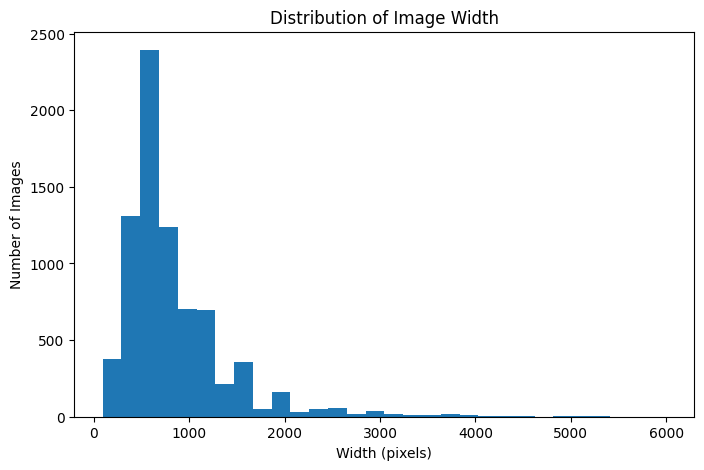

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Width"], bins=30)

plt.title("Distribution of Image Width")
plt.xlabel("Width (pixels)")
plt.ylabel("Number of Images")

plt.show()

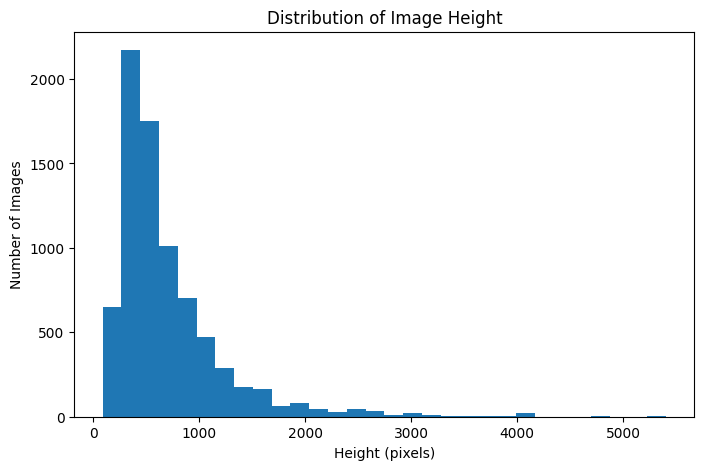

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Height"], bins=30)

plt.title("Distribution of Image Height")
plt.xlabel("Height (pixels)")
plt.ylabel("Number of Images")

plt.show()

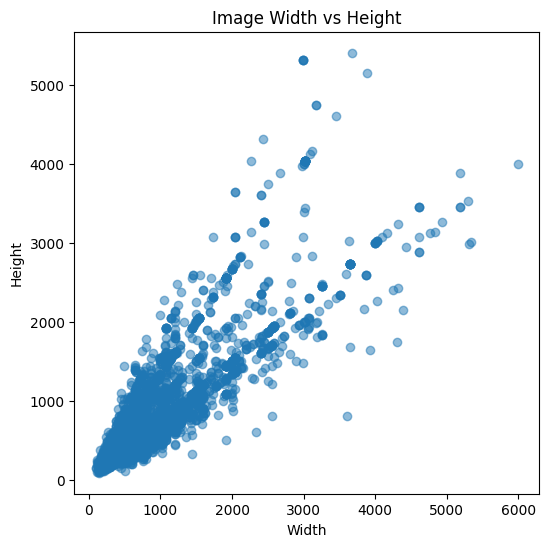

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(df["Width"], df["Height"], alpha=0.5)

plt.title("Image Width vs Height")
plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

In [ ]:
print("Minimum Width:", df["Width"].min())
print("Maximum Width:", df["Width"].max())

print("Minimum Height:", df["Height"].min())
print("Maximum Height:", df["Height"].max())

Minimum Width: 93
Maximum Width: 6000
Minimum Height: 87
Maximum Height: 5408


* The dataset contains images with very different sizes. Image widths range from 93 pixels to 6000 pixels, and heights range from 87 pixels to 5408 pixels, indicating a highly diverse set of image resolutions.

* Most of the images are concentrated between 400 - 1200 pixels in width and 300 - 1000 pixels in height. This suggests the majorith of images arer moderate resolution phtographs.

* a small number of images have very high resolutions these appear as outliers and may increase computational cost during training

* The scatter plot shows a positive correlation between image width and height, meaning larger width  images generally also have larger height.

* images must be resized to a fixed input dimension before train models to a common size.


In [ ]:
import cv2
import numpy as np
import os
from tqdm import tqdm

base_path = "plantseg/plantseg/images"

brightness_values = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    img_name = row["Name"]
    split = row["Split"]

    # convert metadata split to folder name
    if split == "Training":
        folder = "train"
    elif split == "Validation":
        folder = "val"
    else:
        folder = "test"

    img_path = os.path.join(base_path, folder, img_name)

    img = cv2.imread(img_path)

    if img is None:
        brightness_values.append(None)
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = np.mean(gray)

    brightness_values.append(brightness)

df["Brightness"] = brightness_values

100%|██████████| 7774/7774 [00:53<00:00, 144.79it/s]


In [ ]:
df.head()

,Name,Index,Plant,Disease,Resolution,Label file,Mask ratio,URL,License,Split,Width,Height,Aspect_Ratio,Brightness
0,apple_black_rot_1.jpg,0,Apple,apple black rot,640x480,apple_black_rot_1.png,0.040439,https://baijiahao.baidu.com/s?id=1592172448991...,CC-BY-NC,Training,640,480,1.333333,135.156517
1,apple_black_rot_11.jpg,0,Apple,apple black rot,1080x755,apple_black_rot_11.png,0.057550,http://dy.163.com/v2/article/detail/EJ3OGOG605...,CC-BY-NC,Training,1080,755,1.430464,81.571583
2,apple_black_rot_12.jpg,0,Apple,apple black rot,1280x719,apple_black_rot_12.png,0.024791,http://baijiahao.baidu.com/s?id=16205160930871...,CC-BY-NC,Training,1280,719,1.780250,114.343773
3,apple_black_rot_15.jpg,0,Apple,apple black rot,600x355,apple_black_rot_15.png,0.236169,http://www.360doc.cn/article/4310958_180040780...,CC-BY-NC,Training,600,355,1.690141,92.502981
4,apple_black_rot_156.jpg,0,Apple,apple black rot,219x294,apple_black_rot_156.png,0.054344,http://baijiahao.baidu.com/s?id=16352401074244...,CC-BY-NC,Training,219,294,0.744898,140.357609


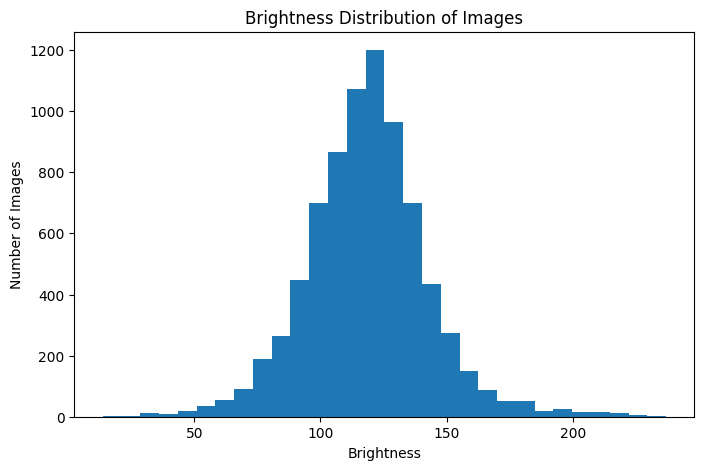

In [ ]:

plt.figure(figsize=(8,5))

plt.hist(df["Brightness"], bins=30)

plt.title("Brightness Distribution of Images")
plt.xlabel("Brightness")
plt.ylabel("Number of Images")

plt.show()

* The brightness values follow an approximately bell-shaped (normal) distribution, indicating that most images have similar lighting conditions.

* The majority of images fall within the brightness range of approximately 90 to 140, suggesting that most images are captured under moderate illumination.

* Only a small number of images have very low brightness (<60) or very high brightness (>180). These represent a small portion of the dataset and are considered outliers.

* Although lighting variation is limited, applying preprocessing techniques such as image normalization or brightness augmentation can help the model become more robust to lighting

##### **Mask ratio**

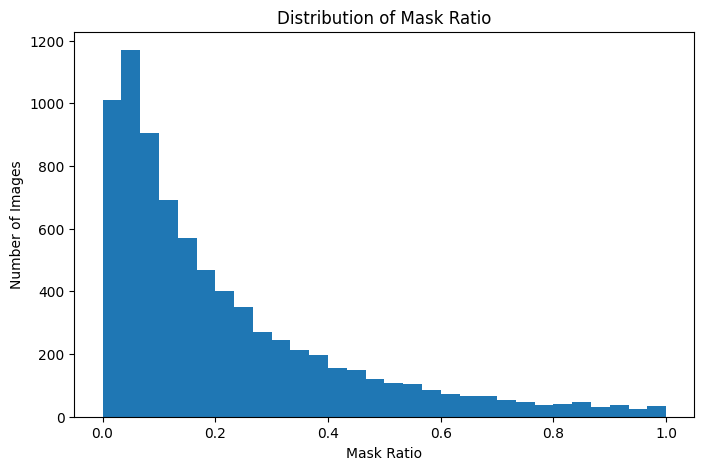

Minimum Mask Ratio: 4.2253181060917016e-05
Maximum Mask Ratio: 1.0
Average Mask Ratio: 0.2136208881573271
Median Mask Ratio: 0.13860423280423279

Small infection area images: 1618
Medium infection area images: 3198
Large infection area images: 2958


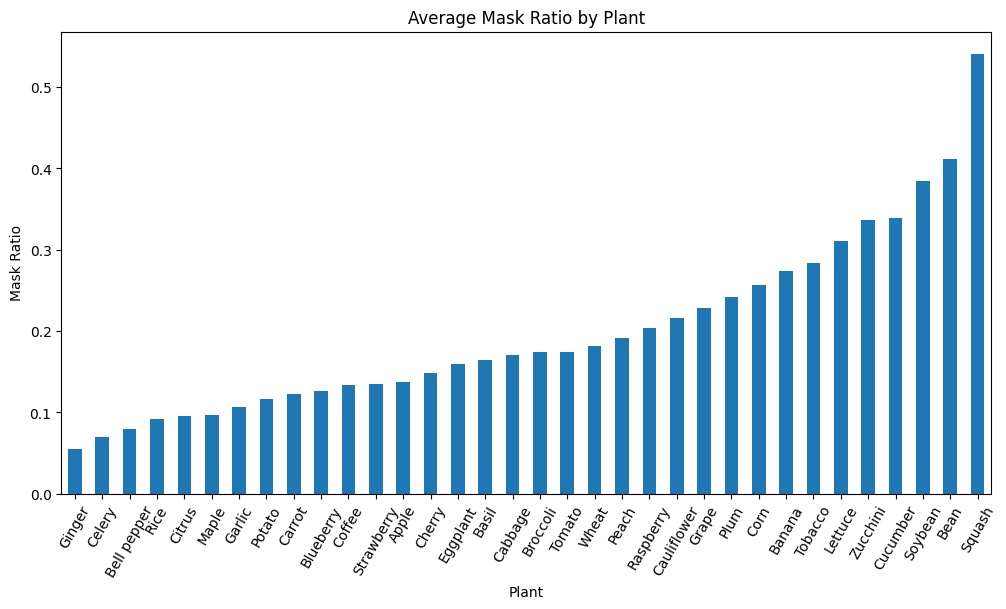

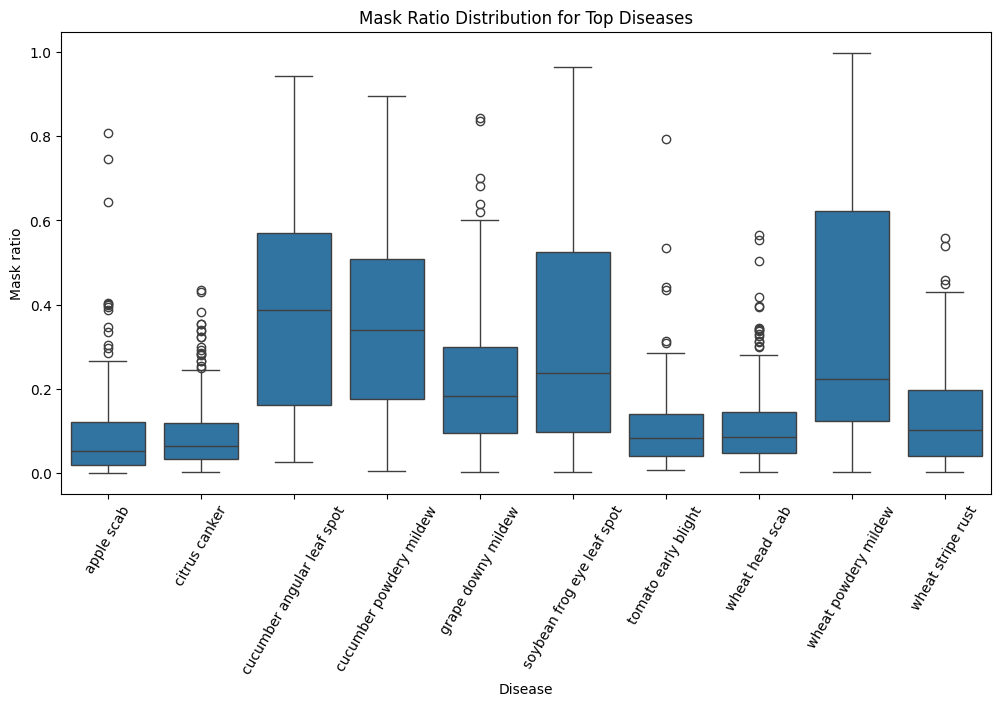

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
plt.hist(df["Mask ratio"], bins=30)
plt.title("Distribution of Mask Ratio")
plt.xlabel("Mask Ratio")
plt.ylabel("Number of Images")
plt.show()

print("Minimum Mask Ratio:", df["Mask ratio"].min())
print("Maximum Mask Ratio:", df["Mask ratio"].max())
print("Average Mask Ratio:", df["Mask ratio"].mean())
print("Median Mask Ratio:", df["Mask ratio"].median())

small = df[df["Mask ratio"] < 0.05]
medium = df[(df["Mask ratio"] >= 0.05) & (df["Mask ratio"] <= 0.20)]
large = df[df["Mask ratio"] > 0.20]

print("\nSmall infection area images:", len(small))
print("Medium infection area images:", len(medium))
print("Large infection area images:", len(large))

mask_by_plant = df.groupby("Plant")["Mask ratio"].mean().sort_values()

plt.figure(figsize=(12,6))
mask_by_plant.plot(kind="bar")
plt.title("Average Mask Ratio by Plant")
plt.xlabel("Plant")
plt.ylabel("Mask Ratio")
plt.xticks(rotation=60)
plt.show()

top_diseases = df["Disease"].value_counts().head(10).index
subset = df[df["Disease"].isin(top_diseases)]

plt.figure(figsize=(12,6))
sns.boxplot(x="Disease", y="Mask ratio", data=subset)
plt.title("Mask Ratio Distribution for Top Diseases")
plt.xticks(rotation=60)
plt.show()

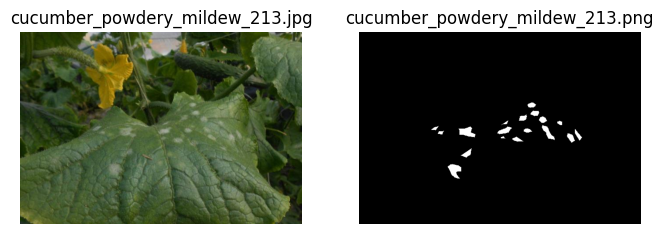

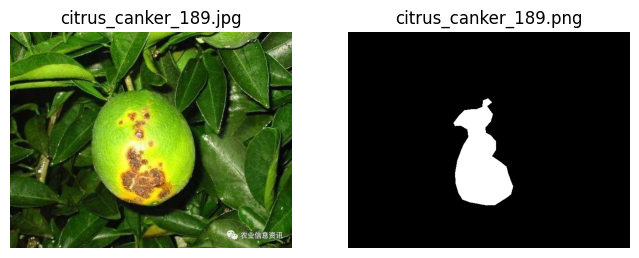

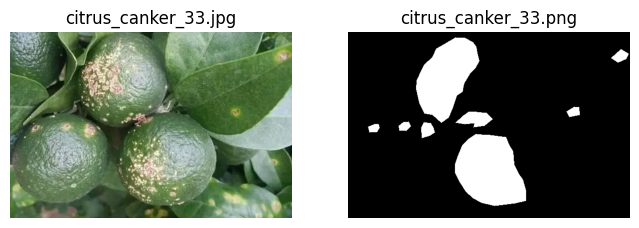

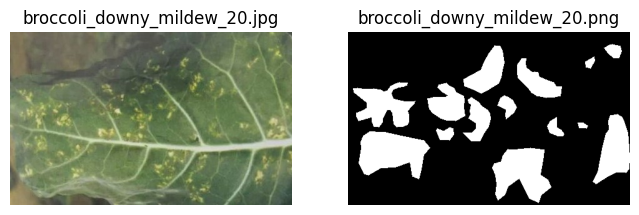

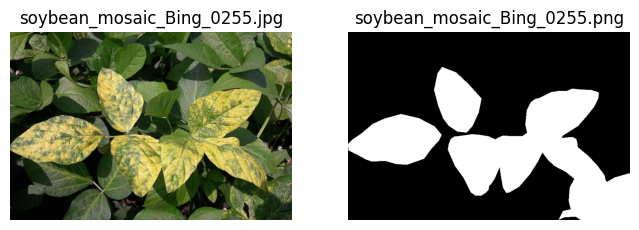

In [ ]:
import random
base_path = "plantseg/plantseg"

img_dir = f"{base_path}/images/train"
mask_dir = f"{base_path}/annotations/train"

img_train = sorted(os.listdir(img_dir))
mask_train = sorted(os.listdir(mask_dir))

indices = random.sample(range(len(img_train)), 5)

for i in indices:
    img_path = os.path.join(img_dir, img_train[i])
    mask_path = os.path.join(mask_dir, mask_train[i])

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, 0)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title(img_train[i])
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask, cmap="gray")
    plt.title(mask_train[i])
    plt.axis("off")

    plt.show()

In [ ]:
import os

base_path = "plantseg/plantseg"

image_dir = f"{base_path}/images/train"
mask_dir = f"{base_path}/annotations/train"

images = sorted(os.listdir(image_dir))
masks = sorted(os.listdir(mask_dir))

print("Images:", len(images))
print("Masks:", len(masks))

for i in range(5):
    print(images[i], "<->", masks[i])

Images: 5367
Masks: 5367
apple_black_rot_1.jpg <-> apple_black_rot_1.png
apple_black_rot_11.jpg <-> apple_black_rot_11.png
apple_black_rot_12.jpg <-> apple_black_rot_12.png
apple_black_rot_15.jpg <-> apple_black_rot_15.png
apple_black_rot_156.jpg <-> apple_black_rot_156.png


In [ ]:
sizes = []

for img in tqdm(images):
    path = os.path.join(image_dir, img)
    image = cv2.imread(path)
    h, w, c = image.shape
    sizes.append((h, w))

sizes_df = pd.DataFrame(sizes, columns=["height", "width"])
sizes_df.describe()

100%|██████████| 5367/5367 [00:29<00:00, 184.58it/s]


,height,width
count,5367.000000,5367.000000
mean,703.585802,837.505310
std,546.296922,577.355608
min,87.000000,93.000000
25%,380.000000,500.000000
50%,522.000000,650.000000
75%,825.000000,1024.000000
max,5408.000000,6000.000000


In [ ]:
sizes_df.value_counts()

height  width
480     640      104
768     1024      94
380     600       64
900     1200      54
400     600       49
                ... 
135     188        1
        250        1
136     210        1
143     220        1
90      120        1
Name: count, Length: 2881, dtype: int64

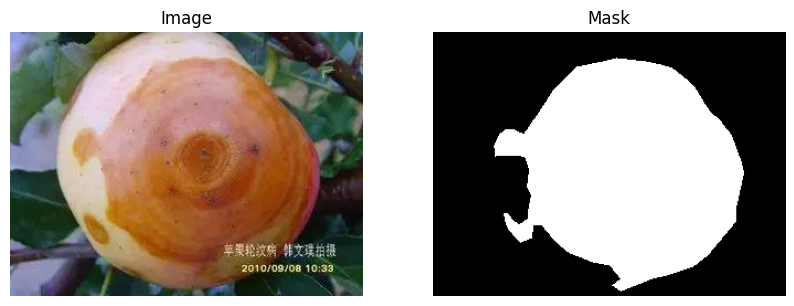

In [ ]:
def show_sample(idx):
    img = cv2.imread(os.path.join(image_dir, images[idx]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(os.path.join(mask_dir, masks[idx]), 0)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.title("Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

show_sample(6)

100%|██████████| 5367/5367 [02:20<00:00, 38.21it/s]


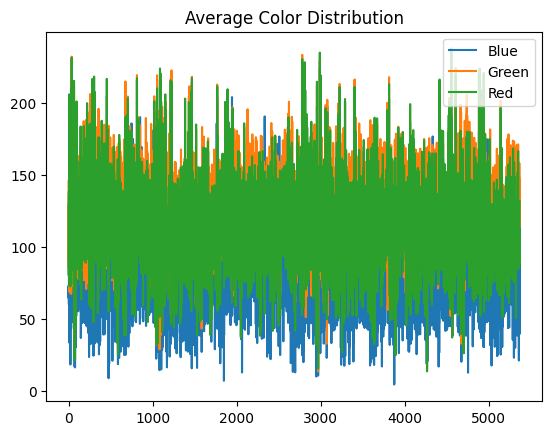

In [ ]:
means = []

for img in tqdm(images):
    image = cv2.imread(os.path.join(image_dir, img))
    means.append(np.mean(image, axis=(0,1)))

means = np.array(means)

plt.plot(means[:,0], label="Blue")
plt.plot(means[:,1], label="Green")
plt.plot(means[:,2], label="Red")
plt.legend()
plt.title("Average Color Distribution")
plt.show()

100%|██████████| 5367/5367 [00:16<00:00, 322.14it/s]


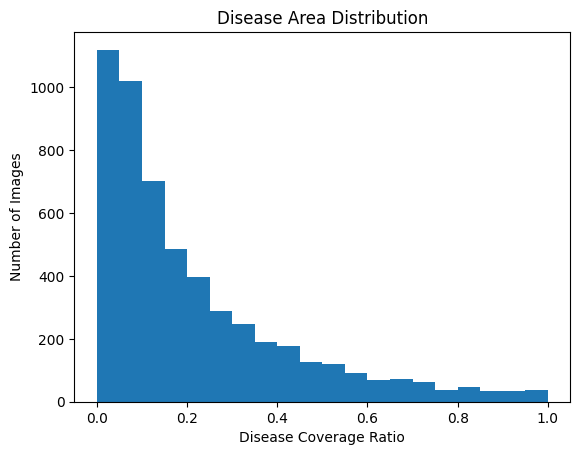

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

coverage = []

for m in tqdm(mask_train):
    mask = cv2.imread(os.path.join(mask_dir, m), 0)

    disease_pixels = np.sum(mask > 0)
    total_pixels = mask.size

    coverage.append(disease_pixels / total_pixels)

plt.hist(coverage, bins=20)
plt.title("Disease Area Distribution")
plt.xlabel("Disease Coverage Ratio")
plt.ylabel("Number of Images")
plt.show()

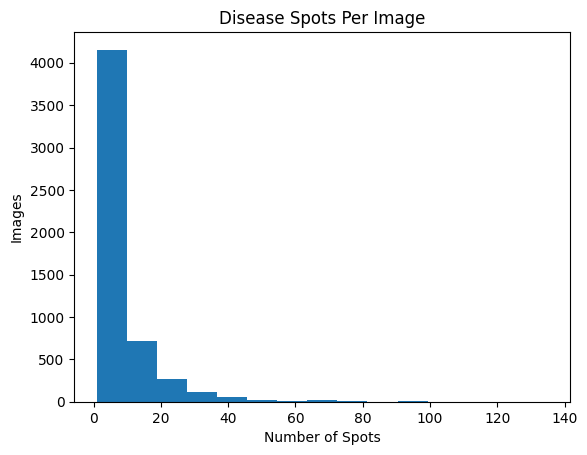

In [ ]:
import cv2

spot_counts = []

for m in mask_train:
    mask = cv2.imread(os.path.join(mask_dir, m), 0)

    num_labels, labels = cv2.connectedComponents(mask)

    spot_counts.append(num_labels - 1)

plt.hist(spot_counts, bins=15)
plt.title("Disease Spots Per Image")
plt.xlabel("Number of Spots")
plt.ylabel("Images")
plt.show()

In [ ]:
!pip install albumentations

In [ ]:
disease_images = []
background_images = []

for img_name, mask_name in zip(img_train, mask_train):

    mask = cv2.imread(os.path.join(mask_dir, mask_name),0)

    if np.sum(mask > 0) > 0:
        disease_images.append((img_name, mask_name))
    else:
        background_images.append((img_name, mask_name))

print("Disease images:", len(disease_images))
print("Background images:", len(background_images))

Disease images: 5367
Background images: 0


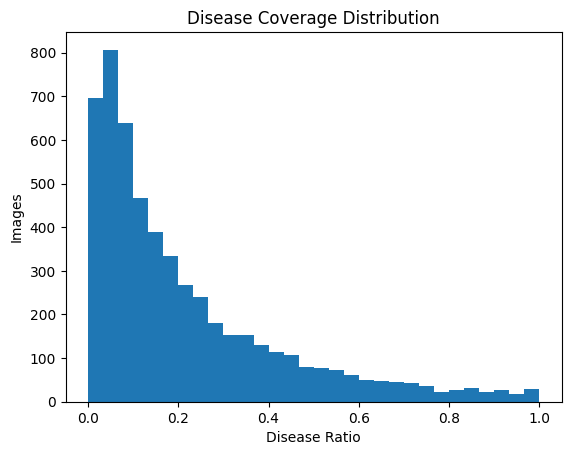

In [ ]:
coverage = []

for m in mask_train:
    mask = cv2.imread(os.path.join(mask_dir, m),0)
    ratio = np.sum(mask > 0) / mask.size
    coverage.append(ratio)

import matplotlib.pyplot as plt
plt.hist(coverage, bins=30)
plt.title("Disease Coverage Distribution")
plt.xlabel("Disease Ratio")
plt.ylabel("Images")
plt.show()

In [ ]:
import os
import cv2
import numpy as np
import albumentations as A
import random

In [ ]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussNoise(p=0.3),
])

In [ ]:
class_counts = {}

for mask_name in tqdm(masks):

    mask = cv2.imread(os.path.join(mask_dir, mask_name),0)

    unique_classes = np.unique(mask)

    for cls in unique_classes:
        class_counts[cls] = class_counts.get(cls,0) + 1

print("Number of classes:", len(class_counts))

100%|██████████| 5367/5367 [01:37<00:00, 54.89it/s]

Number of classes: 116


In [ ]:
import shutil

src_dir = "/content/plant_classification"
combined_dir = "/content/plant_classification_augmented"

shutil.copytree(src_dir, combined_dir)

'/content/plant_classification_augmented'

### **1. Setup and Imports**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

### **2. Data Preparation**

*   Define image dimensions and batch size.
*   Use `ImageDataGenerator` for data augmentation and preprocessing.
*   Load datasets from the `plant_classification_augmented` directory.

In [ ]:
# Define data directories
# Assuming the augmented data is in '/content/plant_classification_augmented'
train_dir = '/content/plant_classification_augmented/train'
val_dir = '/content/plant_classification_augmented/val'
test_dir = '/content/plant_classification_augmented/test'

# Define image dimensions and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Create ImageDataGenerator for training with augmentation and MobileNetV2 preprocessing
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    preprocessing_function=preprocess_input  # MobileNetV2 specific preprocessing
)

# Create ImageDataGenerator for validation/test with only MobileNetV2 preprocessing
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input  # MobileNetV2 specific preprocessing
)

# Load training data first to get the full list of class names
print('Loading training data...')
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True
)

# Get the number of classes and class names from the training generator
# This will be the definitive list of all 115 classes
num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())
print(f"Number of classes (from training data): {num_classes}")

# --- Ensure all class directories exist in validation and test sets ---
# This is crucial to avoid class mismatch errors if some classes are truly absent
# from the physical directories, causing flow_from_directory to report fewer classes.
import os
for class_name in class_names:
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)
print("Ensured all class directories exist in validation and test sets.")

print('Loading validation data...')
validation_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse', # Changed to sparse
    shuffle=False,
    classes=class_names # Explicitly set class order and total classes
)

print('Loading test data...')
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse', # Changed to sparse
    shuffle=False,
    classes=class_names # Explicitly set class order and total classes
)

# Re-check the number of classes reported by each generator for verification
print(f"Train generator reports {train_generator.num_classes} classes.")
print(f"Validation generator reports {validation_generator.num_classes} classes.")
print(f"Test generator reports {test_generator.num_classes} classes.")

Loading training data...
Found 5367 images belonging to 115 classes.
Number of classes (from training data): 115
Ensured all class directories exist in validation and test sets.
Loading validation data...
Found 846 images belonging to 115 classes.
Loading test data...
Found 1561 images belonging to 115 classes.
Train generator reports 115 classes.
Validation generator reports 115 classes.
Test generator reports 115 classes.


### **3. Model Building**

*   Load `MobileNetV2` with pretrained ImageNet weights, excluding the top classification layer.
*   Freeze the base model layers to leverage learned features.
*   Add a custom classification head tailored for our specific task.

In [ ]:
# Load MobileNetV2 pre-trained on ImageNet, excluding the top classification layer
base_model = MobileNetV2(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
                         include_top=False,
                         weights='imagenet')

# Freeze the base model layers
base_model.trainable = False

# Create the custom classification head
inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False) # Ensure base_model runs in inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Combine base model and custom head into a new model
model = keras.Model(inputs, outputs)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 115)            │        14,835 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,436,787 (9.30 MB)

 Trainable params: 178,803 (698.45 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### **4. Model Compilation and Initial Training (Feature Extraction)**

*   Compile the model with the Adam optimizer and categorical cross-entropy loss.
*   Train the model for a few epochs to allow the new classification head to learn.

Epoch 1/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 129s 706ms/step - accuracy: 0.5249 - loss: 1.6251 - val_accuracy: 0.4917 - val_loss: 1.9006
Epoch 2/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 106s 634ms/step - accuracy: 0.5396 - loss: 1.5820 - val_accuracy: 0.5000 - val_loss: 1.8809
Epoch 3/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 106s 628ms/step - accuracy: 0.5407 - loss: 1.5696 - val_accuracy: 0.5071 - val_loss: 1.8992
Epoch 4/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 105s 627ms/step - accuracy: 0.5487 - loss: 1.5700 - val_accuracy: 0.4894 - val_loss: 1.9214
Epoch 5/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 105s 626ms/step - accuracy: 0.5530 - loss: 1.5228 - val_accuracy: 0.5059 - val_loss: 1.8578
Epoch 6/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 105s 629ms/step - accuracy: 0.5597 - loss: 1.5265 - val_accuracy: 0.5047 - val_loss: 1.8801
Epoch 7/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 106s 627ms/step - accuracy: 0.5644 - loss: 1.5062 - val_accuracy: 0.4894 - val_loss: 1.9462
Epoch 8/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 105s 623ms/step - accuracy: 0.5685 -

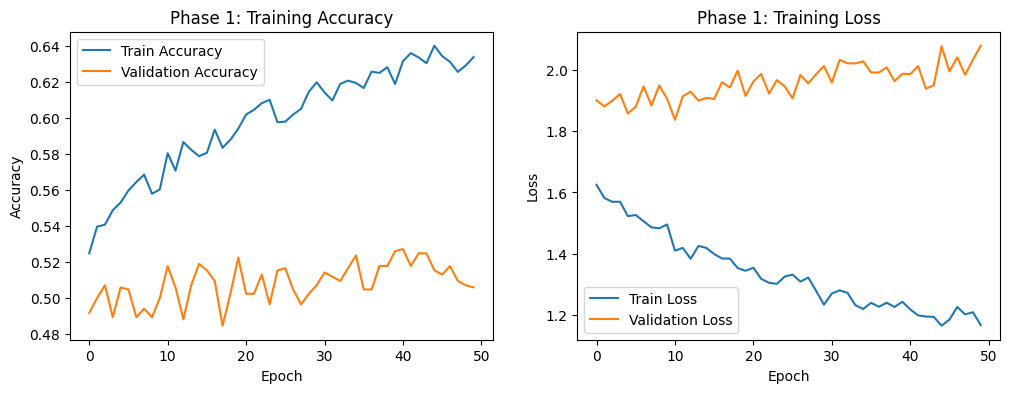

In [ ]:


# Freeze base model
base_model.trainable = False

# Checkpoint only (no early stopping)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
epochs_initial = 50

history_initial = model.fit(
    train_generator,
    epochs=epochs_initial,
    validation_data=validation_generator,
    callbacks=[checkpoint]
)

# -------- GRAPH --------
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_initial.history['accuracy'], label='Train Accuracy')
plt.plot(history_initial.history['val_accuracy'], label='Validation Accuracy')
plt.title('Phase 1: Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_initial.history['loss'], label='Train Loss')
plt.plot(history_initial.history['val_loss'], label='Validation Loss')
plt.title('Phase 1: Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### **5. Fine-tuning**

*   Unfreeze the last 10 layers of the base `MobileNetV2` model.
*   Recompile the model with a very low learning rate to fine-tune the unfrozen layers and the classification head.
*   Continue training for additional epochs.

Epoch 1/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 129s 708ms/step - accuracy: 0.6514 - loss: 1.1330 - val_accuracy: 0.5284 - val_loss: 1.9856
Epoch 2/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 106s 630ms/step - accuracy: 0.6391 - loss: 1.1666 - val_accuracy: 0.5284 - val_loss: 1.9849
Epoch 3/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 107s 633ms/step - accuracy: 0.6514 - loss: 1.1297 - val_accuracy: 0.5296 - val_loss: 1.9843
Epoch 4/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 106s 634ms/step - accuracy: 0.6519 - loss: 1.1403 - val_accuracy: 0.5307 - val_loss: 1.9841
Epoch 5/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 107s 637ms/step - accuracy: 0.6492 - loss: 1.1273 - val_accuracy: 0.5307 - val_loss: 1.9838
Epoch 6/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 107s 633ms/step - accuracy: 0.6471 - loss: 1.1168 - val_accuracy: 0.5307 - val_loss: 1.9833
Epoch 7/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 106s 629ms/step - accuracy: 0.6534 - loss: 1.1204 - val_accuracy: 0.5296 - val_loss: 1.9828
Epoch 8/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 106s 629ms/step - accuracy: 0.6454 -

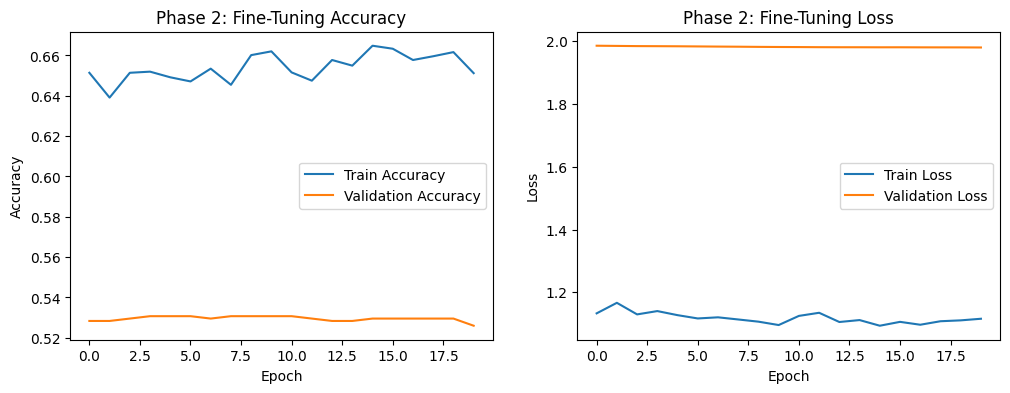

In [ ]:
# Load best model
model = tf.keras.models.load_model('best_model.keras')

# Unfreeze small portion
base_model.trainable = True
fine_tune_at = -10

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Compile with low LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
epochs_fine_tune = 20

history_fine = model.fit(
    train_generator,
    epochs=epochs_fine_tune,
    validation_data=validation_generator,
    callbacks=[checkpoint]
)

# -------- GRAPH --------
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Validation Accuracy')
plt.title('Phase 2: Fine-Tuning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Validation Loss')
plt.title('Phase 2: Fine-Tuning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### **6. Model Evaluation**

*   Evaluate the fine-tuned model on the test dataset.
*   Generate and display a classification report to show precision, recall, and F1-score for each class.
*   Plot a confusion matrix to visualize prediction performance across classes.


Evaluating model on test data...
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 291ms/step - accuracy: 0.5311 - loss: 1.8509

Test Loss: 1.8509
Test Accuracy: 0.5311
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 326ms/step

Total defined classes: 115
Classes present in test set: 114

Classification Report:

                                         precision    recall  f1-score   support

                     apple_mosaic_virus       0.57      0.31      0.40        13
                              apple_rot       0.44      0.33      0.38        12
                             apple_rust       0.33      0.23      0.27        22
                             apple_scab       0.44      0.43      0.43        35
                     banana_anthracnose       0.75      0.67      0.71         9
                      banana_bunchy_top       0.69      0.85      0.76        13
                   banana_cigar_end_rot       1.00      0.78      0.88         9
               banana_cordana_leaf_spot       0.57      0.50      0.53  

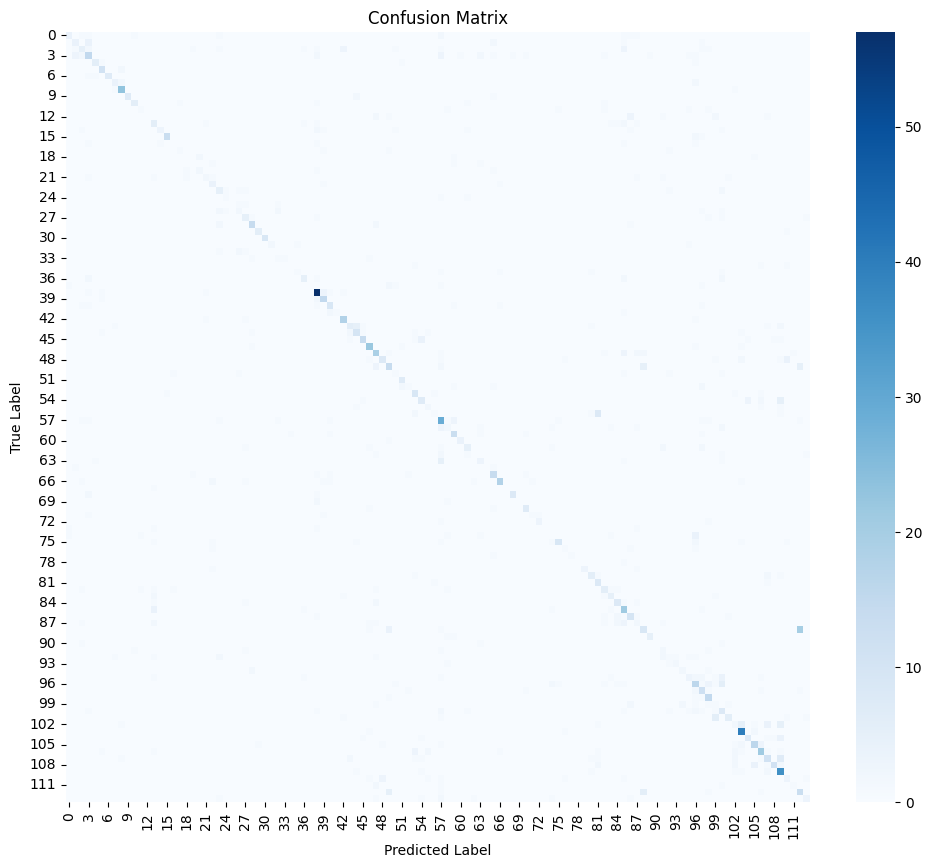

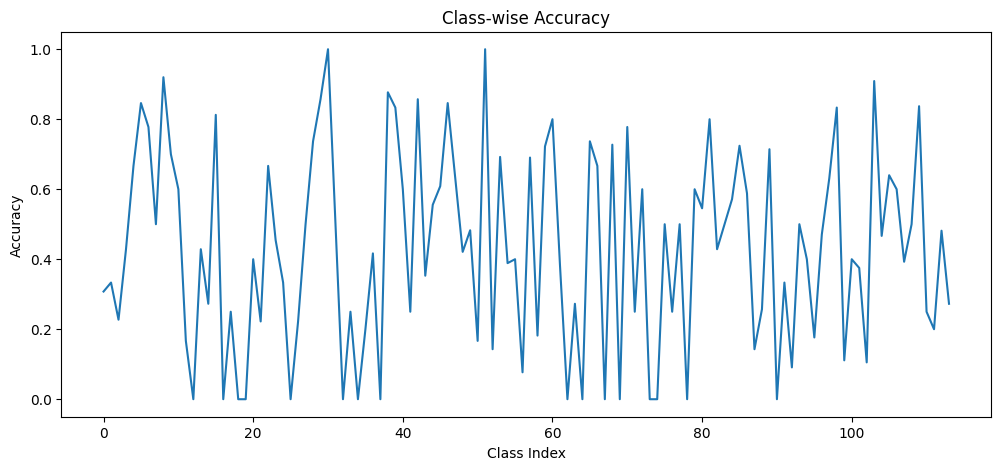

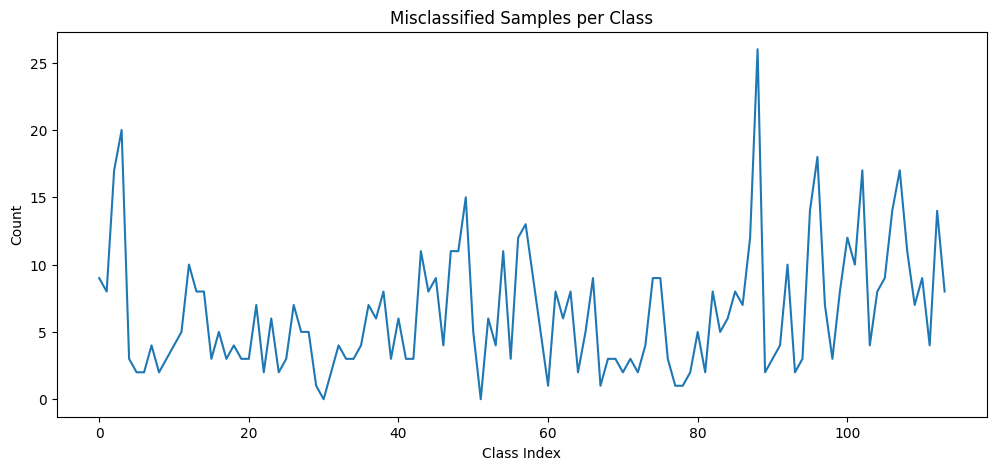

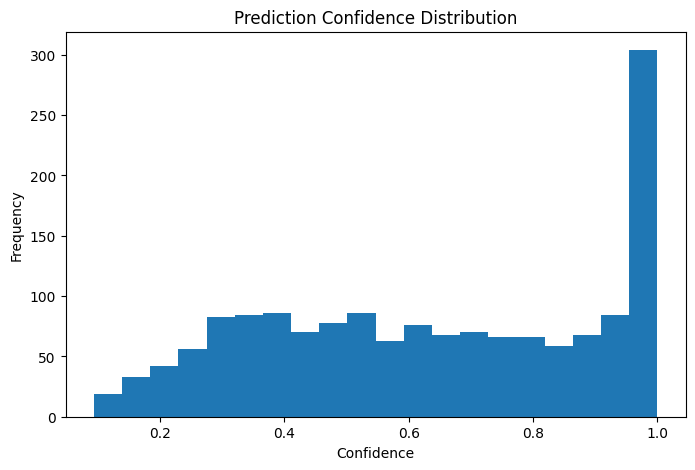

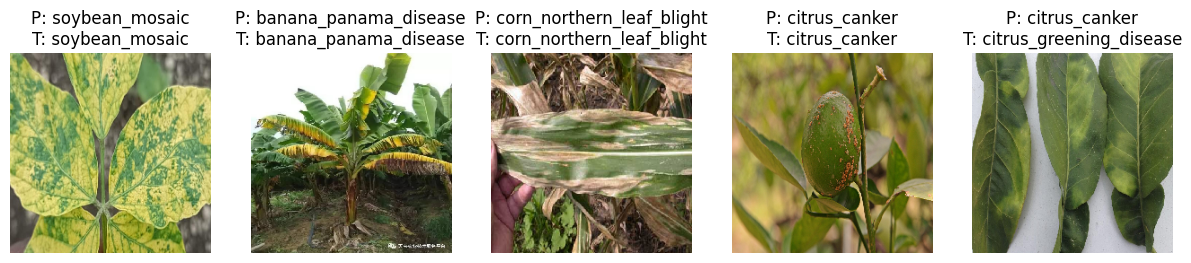


Train classes: 115
Test classes: 115


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

# ---------------------------
# 1. LOAD BEST MODEL
# ---------------------------
model = tf.keras.models.load_model('best_model.keras')

# ---------------------------
# 2. EVALUATE MODEL
# ---------------------------
print("\nEvaluating model on test data...")
loss, accuracy = model.evaluate(test_generator)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# ---------------------------
# 3. PREDICTIONS
# ---------------------------
Y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true_classes = test_generator.classes

# ---------------------------
# 4. HANDLE CLASS NAMES SAFELY (FIXED)
# ---------------------------
class_names = list(test_generator.class_indices.keys())

# Only use labels actually present in test data
unique_labels = np.unique(y_true_classes)

print("\nTotal defined classes:", len(class_names))
print("Classes present in test set:", len(unique_labels))

# ---------------------------
# 5. CLASSIFICATION REPORT (FIXED)
# ---------------------------
print("\nClassification Report:\n")

print(classification_report(
    y_true_classes,
    y_pred_classes,
    labels=unique_labels,
    target_names=[class_names[i] for i in unique_labels],
    zero_division=0
))

# ---------------------------
# 6. CONFUSION MATRIX
# ---------------------------
cm = confusion_matrix(y_true_classes, y_pred_classes, labels=unique_labels)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap='Blues', cbar=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ---------------------------
# 7. CLASS-WISE ACCURACY
# ---------------------------
class_accuracy = cm.diagonal() / (cm.sum(axis=1) + 1e-8)

plt.figure(figsize=(12,5))
plt.plot(class_accuracy)
plt.title("Class-wise Accuracy")
plt.xlabel("Class Index")
plt.ylabel("Accuracy")
plt.show()

# ---------------------------
# 8. MISCLASSIFICATION ANALYSIS
# ---------------------------
misclassified = cm.sum(axis=1) - cm.diagonal()

plt.figure(figsize=(12,5))
plt.plot(misclassified)
plt.title("Misclassified Samples per Class")
plt.xlabel("Class Index")
plt.ylabel("Count")
plt.show()

# ---------------------------
# 9. CONFIDENCE DISTRIBUTION
# ---------------------------
confidence = np.max(Y_pred, axis=1)

plt.figure(figsize=(8,5))
plt.hist(confidence, bins=20)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

# ---------------------------
# 10. SAMPLE PREDICTIONS
# ---------------------------
from tensorflow.keras.preprocessing import image
import random

# Pick random image indices
indices = random.sample(range(len(Y_pred)), 5)

plt.figure(figsize=(15,5))

for i, idx in enumerate(indices):
    plt.subplot(1,5,i+1)

    # Load image from filepath
    img_path = test_generator.filepaths[idx]
    img = image.load_img(img_path, target_size=(224, 224))

    plt.imshow(img)

    # Get predictions
    pred = class_names[y_pred_classes[idx]]
    true = class_names[y_true_classes[idx]]

    plt.title(f"P: {pred}\nT: {true}")
    plt.axis('off')

plt.show()
# ---------------------------
# 11. DEBUG INFO
# ---------------------------
print("\nTrain classes:", len(train_generator.class_indices))
print("Test classes:", len(test_generator.class_indices))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### **7. Model Export**

*   Save the trained model in the Keras `.h5` format.
*   Convert the saved model to TensorFlow Lite (`.tflite`) format for deployment on mobile and edge devices.

In [ ]:
import tensorflow as tf
import os
import json

# ---------------------------
# 1. CREATE SAVE DIRECTORY
# ---------------------------
save_dir = "model_export"
os.makedirs(save_dir, exist_ok=True)

# ---------------------------
# 2. SAVE KERAS MODEL (BEST FORMAT)
# ---------------------------
keras_path = os.path.join(save_dir, "plant_disease_mobilenetv2.keras")
model.save(keras_path)

print(f"✅ Saved Keras model at: {keras_path}")

# ---------------------------
# 3. SAVE CLASS LABELS (VERY IMPORTANT)
# ---------------------------
class_names = list(train_generator.class_indices.keys())

labels_path = os.path.join(save_dir, "labels.json")
with open(labels_path, "w") as f:
    json.dump(class_names, f)

print(f"✅ Saved labels at: {labels_path}")

# ---------------------------
# 4. CONVERT TO TFLITE (OPTIMIZED)
# ---------------------------
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optimization (reduces size + faster inference)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# (Optional but good) ensure float32 compatibility
converter.target_spec.supported_types = [tf.float32]

tflite_model = converter.convert()

tflite_path = os.path.join(save_dir, "plant_disease_mobilenetv2.tflite")

with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"✅ Saved TFLite model at: {tflite_path}")

# ---------------------------
# 5. SHOW FILE SIZES (PROFESSIONAL TOUCH)
# ---------------------------
def get_size(path):
    return round(os.path.getsize(path) / (1024 * 1024), 2)

print("\n📦 Model Sizes:")
print(f"Keras Model: {get_size(keras_path)} MB")
print(f"TFLite Model: {get_size(tflite_path)} MB")

✅ Saved Keras model at: model_export/plant_disease_mobilenetv2.keras
✅ Saved labels at: model_export/labels.json
Saved artifact at '/tmp/tmpt71oyrt5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 115), dtype=tf.float32, name=None)
Captures:
  133770269349968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133770269354000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133770269359568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133770269347088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133770269349392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133770269349008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133770269349200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133770269350160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133770269358992: TensorSpec(shape=(), 

In [ ]:
import shutil
shutil.make_archive('/content/project_files', 'zip', '/content/model_export')

'/content/project_files.zip'

In [ ]:
import shutil
shutil.make_archive('/content/project_files', 'zip', '/content/model_export')

'/content/project_files.zip'

In [ ]:
from google.colab import files
files.download('/content/project_files.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
import os

temp_dir = "/content/temp_backup"

# Clean previous temp folder
if os.path.exists(temp_dir):
    shutil.rmtree(temp_dir)

os.makedirs(temp_dir)

# Copy everything except 'drive'
for item in os.listdir('/content'):
    if item == 'drive':
        continue

    src = os.path.join('/content', item)
    dst = os.path.join(temp_dir, item)

    if os.path.isdir(src):
        shutil.copytree(src, dst)
    else:
        shutil.copy2(src, dst)

print("✅ Files copied (excluding drive)")

# Create zip
zip_path = shutil.make_archive('/content/all_content_no_drive', 'zip', temp_dir)

print(f"✅ Zip created at: {zip_path}")

✅ Files copied (excluding drive)
✅ Zip created at: /content/all_content_no_drive.zip


In [ ]:
from google.colab import files
files.download('/content/all_content_no_drive.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>